# Introvert vs Extrovert Personality Classification Using Machine Learning

## Project Description

This project aims to develop a supervised machine learning model to predict whether an individual is an **Introvert** or an **Extrovert** based on behavioral and social characteristics. The project follows a complete machine learning workflow, including dataset understanding, exploratory data analysis (EDA), data preprocessing, feature engineering, model training, model evaluation, model selection, and model deployment. The final model is deployed as a REST API on a free cloud platform, enabling personality predictions through HTTP POST requests.

# Phase 1 – Project Setup

# Part 2 - Dataset Understanding

In this section, the dataset is loaded and explored to understand its structure, feature names, data types, and overall characteristics before performing preprocessing and machine learning.

## 2.1 Import Required Libraries

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

# Display all columns
pd.set_option("display.max_columns", None)

# Display wider tables
pd.set_option("display.width", 120)

## 2.2 Load Dataset

In [2]:
# Load the dataset

df = pd.read_csv("personality_dataset.csv")

# Display first five rows
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


## 2.3 Display Random Sample Records

Displaying random records helps verify that the dataset has been loaded correctly and provides an unbiased view of the data.

In [3]:
# Display five random records

df.sample(5, random_state=42)

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
141,10.0,Yes,3.0,3.0,Yes,5.0,3.0,Introvert
1557,NaN,No,NaN,5.0,No,14.0,5.0,Extrovert
485,5.0,Yes,0.0,0.0,Yes,0.0,2.0,Introvert
1712,10.0,Yes,2.0,2.0,Yes,2.0,1.0,Introvert
2250,7.0,Yes,0.0,0.0,Yes,2.0,1.0,Introvert


## 2.4 Dataset Shape

The dataset shape shows the total number of rows (observations) and columns (features).

In [4]:
# Display dataset dimensions

rows, columns = df.shape

print(f"Number of Rows    : {rows}")
print(f"Number of Columns : {columns}")

Number of Rows    : 2900
Number of Columns : 8


## 2.5 Column Names

Displaying all feature names helps identify available variables for model development.

In [5]:
# Display column names

print("Dataset Columns:\n")

for column in df.columns:
    print(column)

Dataset Columns:

Time_spent_Alone
Stage_fear
Social_event_attendance
Going_outside
Drained_after_socializing
Friends_circle_size
Post_frequency
Personality


## 2.6 Dataset Information

The dataset information provides data types, number of non-null values, and memory usage.

In [6]:
# Display dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2837 non-null   float64
 1   Stage_fear                 2827 non-null   str    
 2   Social_event_attendance    2838 non-null   float64
 3   Going_outside              2834 non-null   float64
 4   Drained_after_socializing  2848 non-null   str    
 5   Friends_circle_size        2823 non-null   float64
 6   Post_frequency             2835 non-null   float64
 7   Personality                2900 non-null   str    
dtypes: float64(5), str(3)
memory usage: 221.4 KB


## 2.7 Statistical Summary

Generating descriptive statistics helps understand the distribution of numerical features including mean, minimum, maximum, and standard deviation.

In [7]:
# Summary statistics for numerical columns

df.describe()

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,2837.000000,2838.000000,2834.000000,2823.000000,2835.000000
mean,4.505816,3.963354,3.000000,6.268863,3.564727
std,3.479192,2.903827,2.247327,4.289693,2.926582
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,1.000000,3.000000,1.000000
50%,4.000000,3.000000,3.000000,5.000000,3.000000
75%,8.000000,6.000000,5.000000,10.000000,6.000000
max,11.000000,10.000000,7.000000,15.000000,10.000000


## 2.8 Statistical Summary Including Categorical Features

Including categorical columns provides additional information such as unique values, most frequent categories, and their frequencies.

In [8]:
# Summary including categorical features

df.describe(include="all")

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
count,2837.000000,2827,2838.000000,2834.000000,2848,2823.000000,2835.000000,2900
unique,NaN,2,NaN,NaN,2,NaN,NaN,2
top,NaN,No,NaN,NaN,No,NaN,NaN,Extrovert
freq,NaN,1417,NaN,NaN,1441,NaN,NaN,1491
mean,4.505816,NaN,3.963354,3.000000,NaN,6.268863,3.564727,NaN
std,3.479192,NaN,2.903827,2.247327,NaN,4.289693,2.926582,NaN
min,0.000000,NaN,0.000000,0.000000,NaN,0.000000,0.000000,NaN
25%,2.000000,NaN,2.000000,1.000000,NaN,3.000000,1.000000,NaN
50%,4.000000,NaN,3.000000,3.000000,NaN,5.000000,3.000000,NaN
75%,8.000000,NaN,6.000000,5.000000,NaN,10.000000,6.000000,NaN


## 2.9 Data Types of Features

Identifying the data type of each feature helps determine appropriate preprocessing techniques such as encoding or scaling.

In [9]:
# Display data types

df.dtypes

Time_spent_Alone             float64
Stage_fear                       str
Social_event_attendance      float64
Going_outside                float64
Drained_after_socializing        str
Friends_circle_size          float64
Post_frequency               float64
Personality                      str
dtype: object

## 2.10 Identify Target Variable

The target variable is the column that the machine learning model will predict.

In [10]:
# Display target variable

target = "Personality"

print("Target Variable :", target)

print("\nUnique Classes:")

print(df[target].unique())

Target Variable : Personality

Unique Classes:
<ArrowStringArray>
['Extrovert', 'Introvert']
Length: 2, dtype: str


## 2.11 Feature Categories

Separate input features and target feature.

In [11]:
# Input features

X = df.drop("Personality", axis=1)

# Target feature

y = df["Personality"]

print("Feature Count :", X.shape[1])

print("Target Column :", y.name)

Feature Count : 7
Target Column : Personality


## 2.12 Dataset Overview

The dataset contains demographic and behavioral features describing individuals. The objective is to classify each individual as either an Introvert or an Extrovert based on these characteristics.

The dataset contains both numerical and categorical variables, making it suitable for supervised binary classification after appropriate preprocessing.

# Part 3 - Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the dataset by examining feature distributions, identifying missing values and duplicates, analyzing relationships between variables, detecting potential outliers, and understanding the target class distribution before data preprocessing and model development.

## 3.1 Import Visualization Libraries

In [12]:
# Import visualization libraries

import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings
plt.style.use("ggplot")
%matplotlib inline

## 3.2 Check Missing Values

Missing values are identified to determine whether any preprocessing is required before model training.

In [13]:
# Check missing values

missing_values = df.isnull().sum()

missing_values

Time_spent_Alone             63
Stage_fear                   73
Social_event_attendance      62
Going_outside                66
Drained_after_socializing    52
Friends_circle_size          77
Post_frequency               65
Personality                   0
dtype: int64

## 3.3 Check Duplicate Records

Duplicate records can negatively affect model performance and should be identified before preprocessing.

In [14]:
# Check duplicate rows

duplicate_rows = df.duplicated().sum()

print(f"Duplicate Records : {duplicate_rows}")

Duplicate Records : 388


## 3.4 Target Class Distribution

The distribution of Introvert and Extrovert classes is examined to identify whether the dataset is balanced.

In [15]:
# Target class distribution

df["Personality"].value_counts()

Personality
Extrovert    1491
Introvert    1409
Name: count, dtype: int64

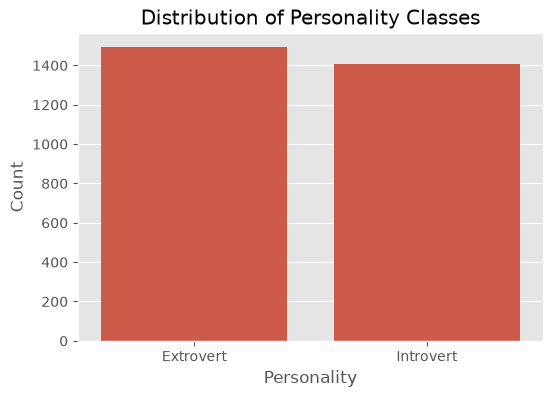

In [16]:
# Visualize target distribution

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Personality"
)

plt.title("Distribution of Personality Classes")
plt.xlabel("Personality")
plt.ylabel("Count")

plt.show()

## 3.5 Distribution of Numerical Features

Histograms are used to visualize the distribution of numerical variables and identify skewness or unusual patterns.

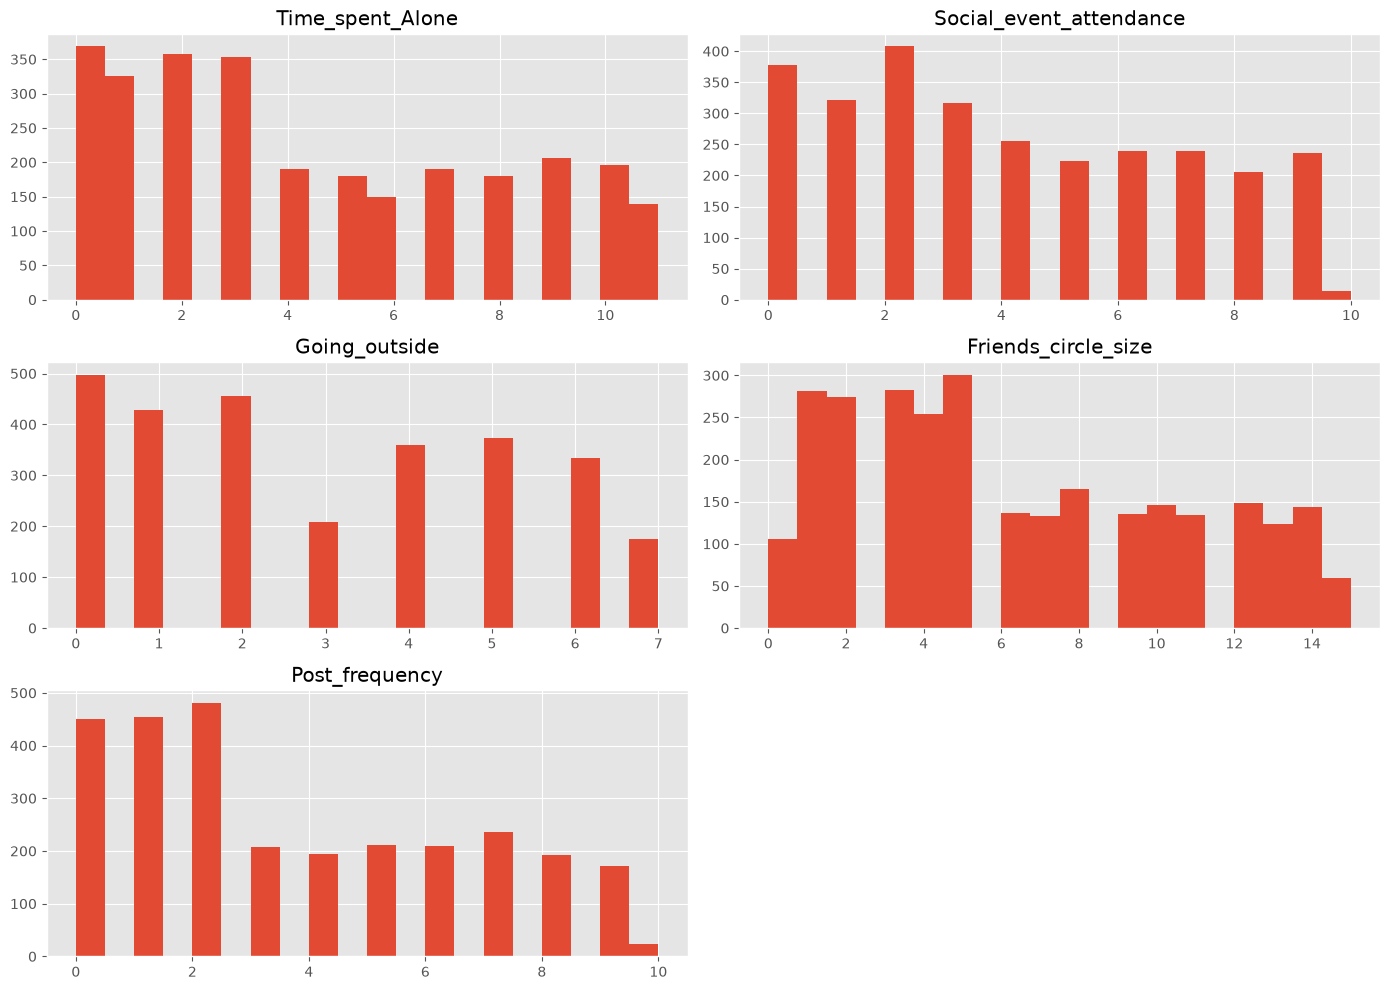

In [17]:
# Histograms for numerical features

numerical_columns = df.select_dtypes(include=np.number).columns

df[numerical_columns].hist(
    figsize=(14,10),
    bins=20
)

plt.tight_layout()

plt.show()

## 3.6 Distribution of Categorical Features

Count plots are used to understand the frequency distribution of categorical variables.

C:\Users\USER\AppData\Local\Temp\ipykernel_5024\2314671466.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


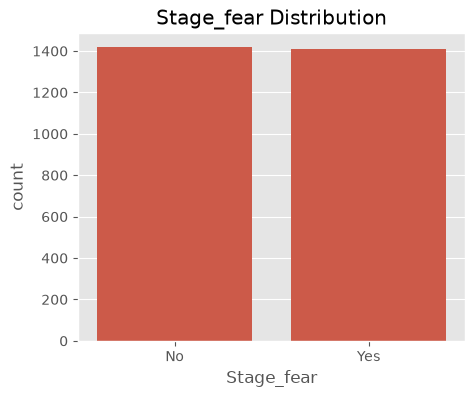

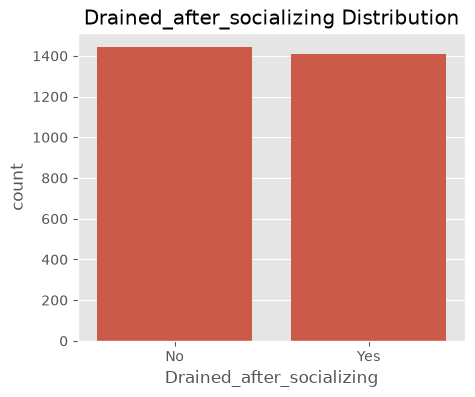

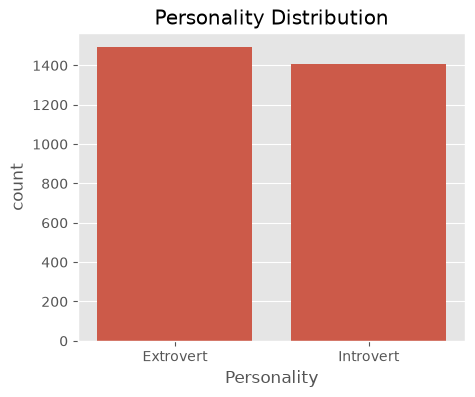

In [18]:
# Categorical feature distributions

categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    
    plt.figure(figsize=(5,4))
    
    sns.countplot(
        data=df,
        x=column
    )
    
    plt.title(f"{column} Distribution")
    
    plt.show()

## 3.7 Correlation Analysis

The correlation matrix helps identify relationships among numerical features.

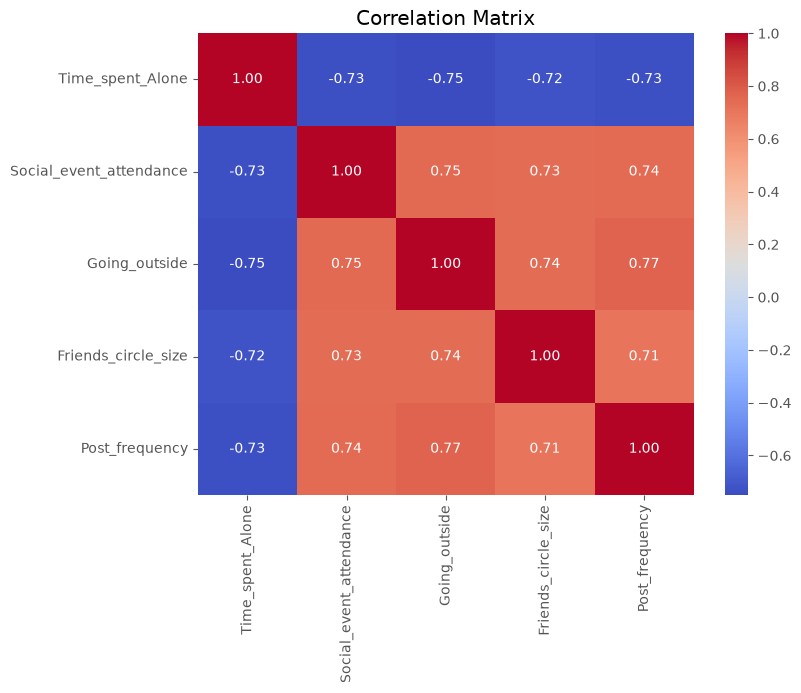

In [19]:
# Correlation matrix

plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

## 3.8 Boxplots for Outlier Detection

Boxplots provide a visual representation of the spread of numerical features and help identify potential outliers.

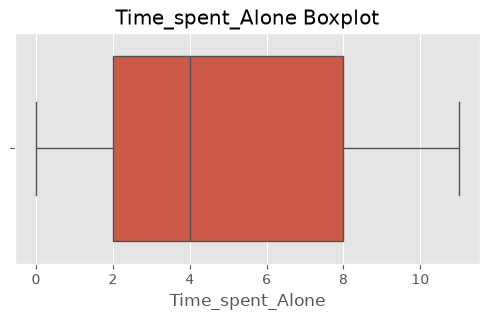

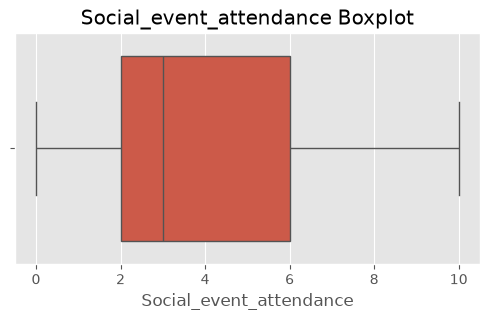

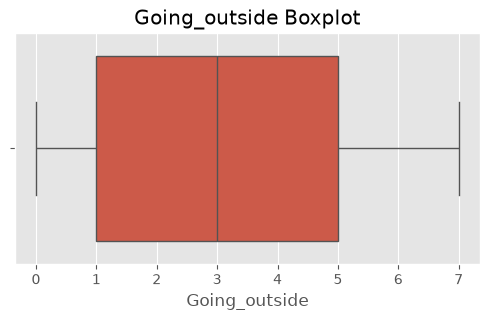

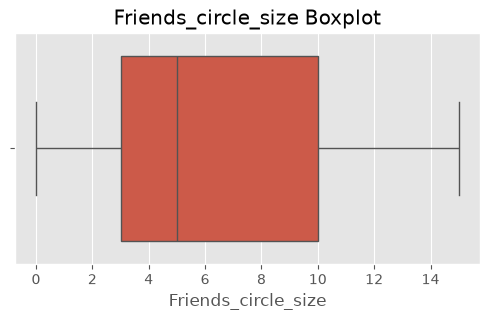

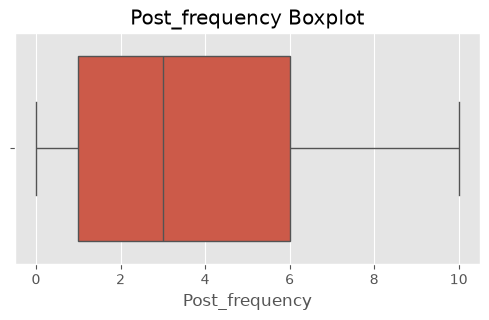

In [20]:
# Boxplots for numerical columns

for column in numerical_columns:

    plt.figure(figsize=(6,3))

    sns.boxplot(
        x=df[column]
    )

    plt.title(f"{column} Boxplot")

    plt.show()

## 3.9 Pairwise Relationships Between Numerical Features

Pairwise plots help visualize relationships between numerical variables and reveal possible clustering patterns.

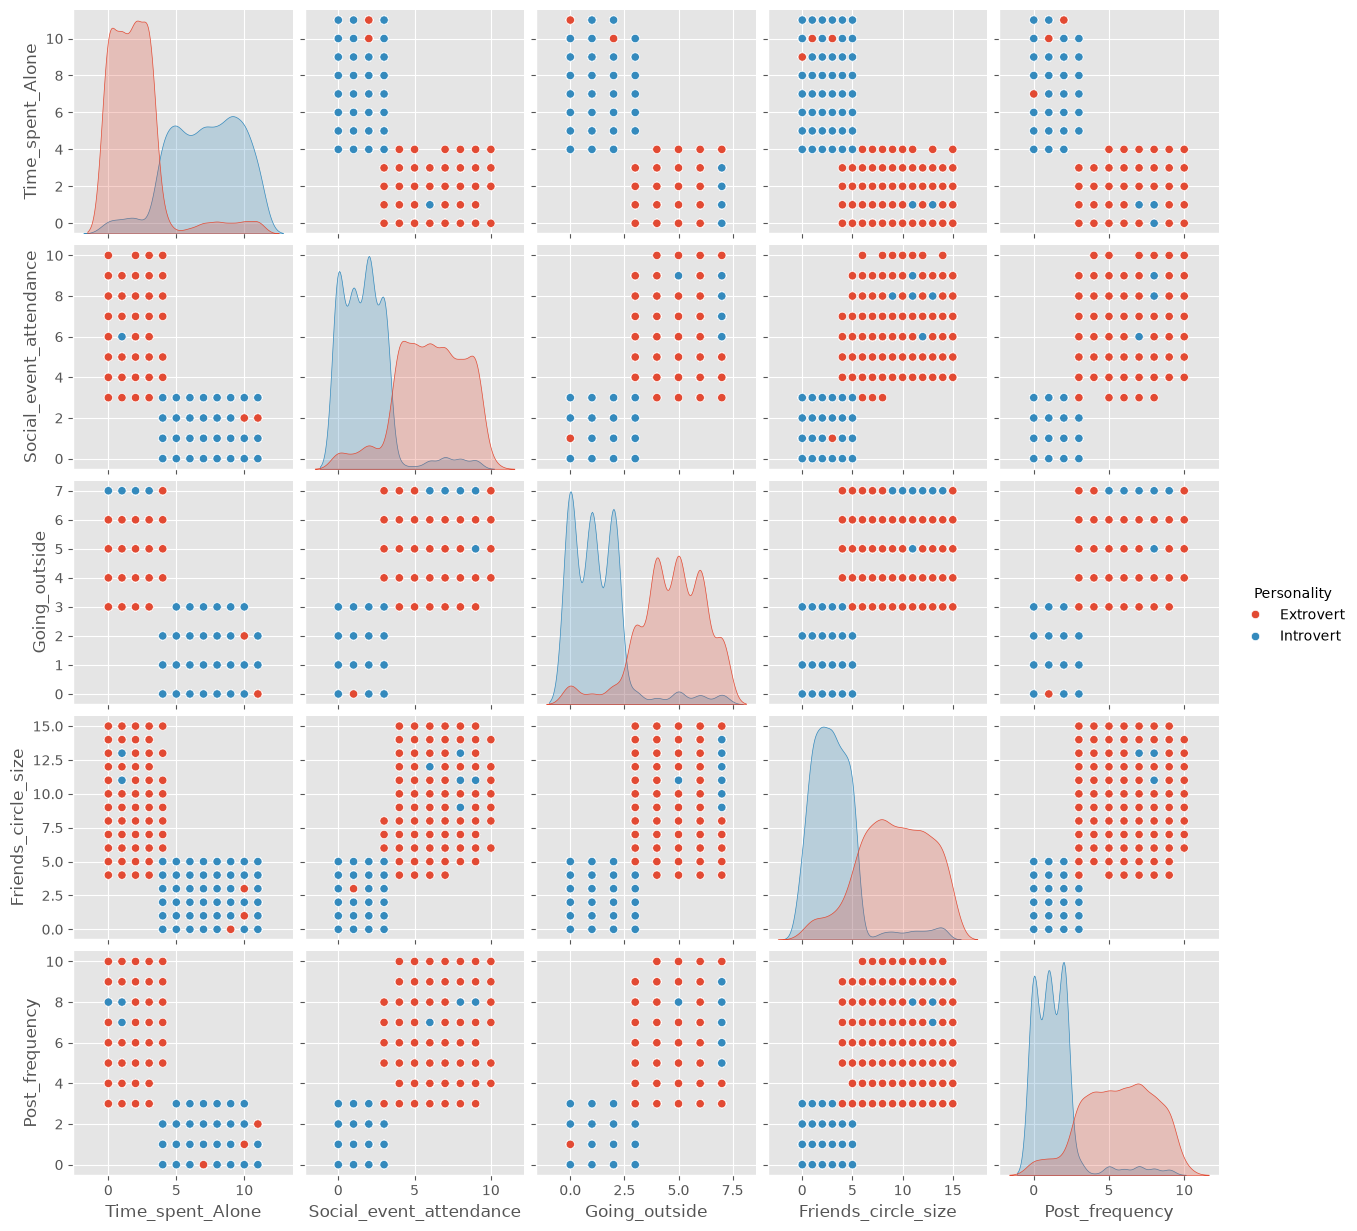

In [21]:
# Pairplot

sns.pairplot(
    df,
    hue="Personality"
)

plt.show()

## 3.10 Exploratory Data Analysis Summary

### Key Findings

- The dataset contains both numerical and categorical features.
- Missing values and duplicate records were examined for data quality assessment.
- The target classes (Introvert and Extrovert) were analyzed to evaluate class balance.
- Numerical feature distributions and categorical frequencies were visualized.
- Correlation analysis revealed relationships among numerical variables.
- Boxplots were used to inspect potential outliers.
- Pairwise visualizations provided additional insight into feature interactions.

The observations from this analysis will guide the data preprocessing and feature engineering steps in the next phase.

# Part 4 - Data Preprocessing

Data preprocessing prepares the dataset for machine learning by improving data quality and organizing the data into a suitable format. This phase includes handling missing values, removing duplicate records, separating features and the target variable, splitting the dataset, and creating a preprocessing pipeline for numerical and categorical features.

## 4.1 Create a Copy of the Dataset

A copy of the original dataset is created to preserve the raw data while performing preprocessing operations.

In [22]:
# Create a working copy of the dataset

data = df.copy()

# Display first five rows

data.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


## 4.2 Handle Missing Values

Missing values are identified and replaced using appropriate imputation techniques. Numerical features are imputed using the median, while categorical features are imputed using the most frequent value.

In [23]:
# Display missing values before preprocessing

print("Missing Values Before Processing\n")
print(data.isnull().sum())

Missing Values Before Processing

Time_spent_Alone             63
Stage_fear                   73
Social_event_attendance      62
Going_outside                66
Drained_after_socializing    52
Friends_circle_size          77
Post_frequency               65
Personality                   0
dtype: int64


In [25]:
# Fill missing values

# Target column
target_column = "Personality"

# Numerical columns (excluding target if present)
numerical_columns = data.select_dtypes(include=["int64", "float64"]).columns.tolist()
if target_column in numerical_columns:
    numerical_columns.remove(target_column)

# Categorical columns (excluding target)
categorical_columns = data.select_dtypes(include=["object"]).columns.tolist()
if target_column in categorical_columns:
    categorical_columns.remove(target_column)

# Fill numerical features using median
for column in numerical_columns:
    data[column] = data[column].fillna(data[column].median())

# Fill categorical features using mode
for column in categorical_columns:
    data[column] = data[column].fillna(data[column].mode()[0])

print("Missing values handled successfully.")

C:\Users\USER\AppData\Local\Temp\ipykernel_5024\2621552348.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = data.select_dtypes(include=["object"]).columns.tolist()


Missing values handled successfully.


In [26]:
# Verify missing values

print(data.isnull().sum())

Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
Personality                  0
dtype: int64


## 4.3 Remove Duplicate Records

Duplicate records are removed to prevent repeated observations from influencing the machine learning model.

In [27]:
# Dataset shape before removing duplicates

print("Shape Before:", data.shape)

# Remove duplicate rows

data.drop_duplicates(inplace=True)

print("Shape After :", data.shape)

Shape Before: (2900, 8)
Shape After : (2452, 8)


## 4.4 Separate Features and Target Variable

The input features (X) and target variable (y) are separated for model development.

In [28]:
# Features

X = data.drop("Personality", axis=1)

# Target

y = data["Personality"]

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (2452, 7)
Target Shape  : (2452,)


## 4.5 Identify Numerical and Categorical Features

The dataset contains both numerical and categorical variables. Identifying these feature types is essential for building an appropriate preprocessing pipeline.

In [29]:
# Numerical columns

numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Categorical columns

categorical_features = X.select_dtypes(include="object").columns.tolist()

print("Numerical Features")
print(numerical_features)

print("\nCategorical Features")
print(categorical_features)

Numerical Features
['Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Friends_circle_size', 'Post_frequency']

Categorical Features
['Stage_fear', 'Drained_after_socializing']


C:\Users\USER\AppData\Local\Temp\ipykernel_5024\464847827.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include="object").columns.tolist()


## 4.6 Split the Dataset

The dataset is divided into training and testing sets. The training set is used for model learning, while the testing set is reserved for evaluating model performance.

In [30]:
from sklearn.model_selection import train_test_split

# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (1961, 7)
Testing Features  : (491, 7)
Training Labels   : (1961,)
Testing Labels    : (491,)


## 4.7 Create the Preprocessing Pipeline

A preprocessing pipeline is created using a ColumnTransformer. Numerical features are standardized, while categorical features are encoded using One-Hot Encoding. This ensures that preprocessing is applied consistently during both training and prediction.

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [32]:
# Create preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print(preprocessor)

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Time_spent_Alone', 'Social_event_attendance',
                                  'Going_outside', 'Friends_circle_size',
                                  'Post_frequency']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Stage_fear', 'Drained_after_socializing'])])


## 4.8 Data Preprocessing Summary

The dataset has been successfully prepared for machine learning.

### Completed preprocessing steps

- Created a working copy of the dataset.
- Handled missing values.
- Removed duplicate records.
- Separated input features and target variable.
- Identified numerical and categorical features.
- Split the dataset into training and testing sets.
- Built a preprocessing pipeline using `ColumnTransformer`, `StandardScaler`, and `OneHotEncoder`.

The processed data is now ready for model development in the next phase.

# Part 5 - Feature Engineering

Feature engineering is the process of preparing input features to improve machine learning model performance. For this dataset, feature engineering primarily involves selecting relevant features, applying preprocessing transformations through the pipeline, and preparing the final feature matrix for model training.

## 5.1 Review Input Features

Before training the model, the selected input features are reviewed to ensure that only relevant variables are included.

In [33]:
# Display input feature names

print("Input Features\n")

for feature in X.columns:
    print("-", feature)

Input Features

- Time_spent_Alone
- Stage_fear
- Social_event_attendance
- Going_outside
- Drained_after_socializing
- Friends_circle_size
- Post_frequency


## 5.2 Verify Feature Types

The numerical and categorical features identified during preprocessing are reviewed before transformation.

In [34]:
print("Numerical Features\n")
print(numerical_features)

print("\nCategorical Features\n")
print(categorical_features)

Numerical Features

['Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Friends_circle_size', 'Post_frequency']

Categorical Features

['Stage_fear', 'Drained_after_socializing']


## 5.3 Apply the Preprocessing Pipeline

The preprocessing pipeline is fitted using the training data and applied to both the training and testing datasets. This ensures that all transformations are learned only from the training data, preventing data leakage.

In [35]:
# Fit and transform training data

X_train_processed = preprocessor.fit_transform(X_train)

# Transform testing data

X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed successfully.")

Preprocessing completed successfully.


## 5.4 Verify Processed Feature Matrix

After preprocessing, the transformed feature matrices are inspected to confirm that they are ready for machine learning model training.

In [36]:
print("Training Feature Matrix Shape :", X_train_processed.shape)
print("Testing Feature Matrix Shape  :", X_test_processed.shape)

Training Feature Matrix Shape : (1961, 9)
Testing Feature Matrix Shape  : (491, 9)


## 5.5 Retrieve Engineered Feature Names

After One-Hot Encoding, categorical variables are expanded into binary features. The complete list of transformed feature names is retrieved for inspection.

In [37]:
# Retrieve feature names

feature_names = preprocessor.get_feature_names_out()

print("Total Features After Transformation :", len(feature_names))

feature_names

Total Features After Transformation : 9


array(['num__Time_spent_Alone', 'num__Social_event_attendance',
       'num__Going_outside', 'num__Friends_circle_size',
       'num__Post_frequency', 'cat__Stage_fear_No', 'cat__Stage_fear_Yes',
       'cat__Drained_after_socializing_No',
       'cat__Drained_after_socializing_Yes'], dtype=object)

## 5.6 Display the First Engineered Samples

The processed training data is converted into a DataFrame for easier inspection.

In [39]:
processed_train = pd.DataFrame(
    X_train_processed,
    columns=feature_names
)

processed_train.head()

,num__Time_spent_Alone,num__Social_event_attendance,num__Going_outside,num__Friends_circle_size,num__Post_frequency,cat__Stage_fear_No,cat__Stage_fear_Yes,cat__Drained_after_socializing_No,cat__Drained_after_socializing_Yes
0,0.510561,-1.101046,-1.453212,-0.369098,-0.971530,0.0,1.0,0.0,1.0
1,0.220103,-0.412651,-1.453212,-1.067073,-0.630285,0.0,1.0,0.0,1.0
2,-0.651273,-0.412651,0.354717,1.957488,-0.289040,1.0,0.0,1.0,0.0
3,0.801019,-0.412651,-1.001230,-1.067073,-1.312776,0.0,1.0,0.0,1.0
4,-0.651273,0.964139,0.354717,-0.136439,0.052205,1.0,0.0,1.0,0.0


## 5.7 Feature Engineering Summary

### Completed Feature Engineering Tasks

- Verified all selected input features.
- Confirmed numerical and categorical feature groups.
- Applied the preprocessing pipeline to the training and testing datasets.
- Standardized numerical variables using `StandardScaler`.
- Encoded categorical variables using `OneHotEncoder`.
- Generated the final engineered feature matrix.
- Verified the transformed dataset and feature names.

The engineered feature matrix is now ready for machine learning model development.

# Part 6 - Machine Learning Model Development

In this phase, multiple supervised machine learning classification algorithms are trained using the prepared dataset. Each model is implemented with the same preprocessing pipeline to ensure a fair comparison. The trained models will later be evaluated to identify the best-performing classifier.

## 6.1 Import Machine Learning Algorithms

In [40]:
# Machine Learning Algorithms

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC

## 6.2 Define Machine Learning Models

A collection of classification algorithms is created for training and comparison.

In [41]:
# Dictionary of machine learning models

models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

print("Total Models :", len(models))

Total Models : 6


## 6.3 Train Machine Learning Models

Each model is trained using the preprocessing pipeline followed by the classification algorithm.

In [42]:
trained_models = {}

for model_name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    trained_models[model_name] = pipeline

    print(f"{model_name} trained successfully.")

Logistic Regression trained successfully.
K-Nearest Neighbors trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
Support Vector Machine trained successfully.
Gradient Boosting trained successfully.


## 6.4 Verify Trained Models

The trained models are displayed to confirm successful completion of the training process.

In [43]:
print("Trained Models\n")

for model in trained_models.keys():
    print(model)

Trained Models

Logistic Regression
K-Nearest Neighbors
Decision Tree
Random Forest
Support Vector Machine
Gradient Boosting


## 6.5 Display Pipeline Structure

The pipeline combines preprocessing and classification into a single workflow, ensuring consistent data transformation during both training and prediction.

In [44]:
trained_models["Random Forest"]

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['Extrovert','Introvert']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Time_spent_Alone','Stage_fear','Social_event_attendance',..., 'Drained_after_socializing','Friends_circle_size','Post_frequency']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns 

## 6.6 Verify Prediction Capability

A small sample from the testing dataset is used to verify that the trained models can successfully generate predictions.

In [46]:
sample_predictions = trained_models["Random Forest"].predict(
    X_test.head()
)

sample_predictions

array(['Extrovert', 'Extrovert', 'Extrovert', 'Introvert', 'Introvert'],
      dtype=object)

## 6.7 Machine Learning Development Summary

### Completed Tasks

- Imported multiple supervised classification algorithms.
- Defined six machine learning models.
- Created a preprocessing and classification pipeline.
- Trained all models using the training dataset.
- Verified successful model training.
- Generated sample predictions to confirm correct operation.

The trained models are now ready for detailed performance evaluation in the next phase.

# Part 7 - Model Evaluation

This phase evaluates the performance of all trained machine learning models using the testing dataset. Multiple evaluation metrics are calculated to compare model performance and identify the most suitable classifier for personality prediction.

## 7.1 Import Evaluation Metrics

In [47]:
# Import evaluation metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

## 7.2 Evaluate All Machine Learning Models

Each trained model is evaluated using Accuracy, Precision, Recall, and F1-Score.

In [48]:
# Store evaluation results

results = []

for model_name, model in trained_models.items():

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        pos_label="Extrovert"
    )

    recall = recall_score(
        y_test,
        y_pred,
        pos_label="Extrovert"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        pos_label="Extrovert"
    )

    results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1
    ])

print("Model evaluation completed successfully.")

Model evaluation completed successfully.


## 7.3 Model Performance Comparison

In [49]:
# Create comparison table

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Support Vector Machine,0.930754,0.942238,0.935484,0.938849
1,Gradient Boosting,0.928717,0.938849,0.935484,0.937163
2,K-Nearest Neighbors,0.914460,0.927798,0.921147,0.924460
3,Logistic Regression,0.912424,0.912587,0.935484,0.923894
4,Random Forest,0.898167,0.896194,0.928315,0.911972
5,Decision Tree,0.841141,0.850174,0.874552,0.862191


## 7.4 Best Performing Model

In [50]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Model :", best_model_name)

Best Model : Support Vector Machine


## 7.5 Evaluate the Best Model

In [51]:
best_model = trained_models[best_model_name]

y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    pos_label="Extrovert"
)

recall = recall_score(
    y_test,
    y_pred,
    pos_label="Extrovert"
)

f1 = f1_score(
    y_test,
    y_pred,
    pos_label="Extrovert"
)

print("="*50)
print("MODEL PERFORMANCE")
print("="*50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

MODEL PERFORMANCE
Accuracy : 0.9308
Precision: 0.9422
Recall   : 0.9355
F1 Score : 0.9388


## 7.6 Classification Report

In [52]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

   Extrovert       0.94      0.94      0.94       279
   Introvert       0.92      0.92      0.92       212

    accuracy                           0.93       491
   macro avg       0.93      0.93      0.93       491
weighted avg       0.93      0.93      0.93       491



## 7.7 Confusion Matrix

In [53]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[261,  18],
       [ 16, 196]])

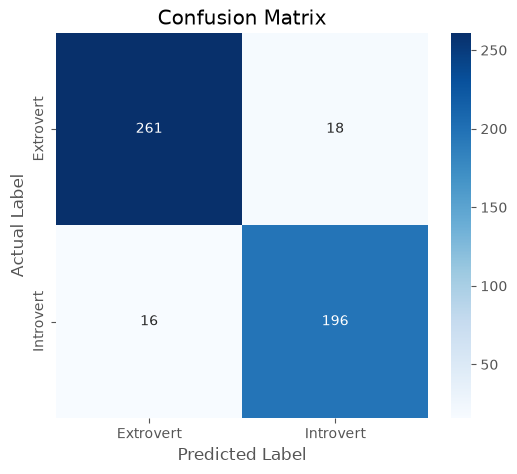

In [54]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Extrovert","Introvert"],
    yticklabels=["Extrovert","Introvert"]
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.show()

## 7.8 Performance Comparison Chart

The overall accuracy of all machine learning models is visualized to simplify model comparison.

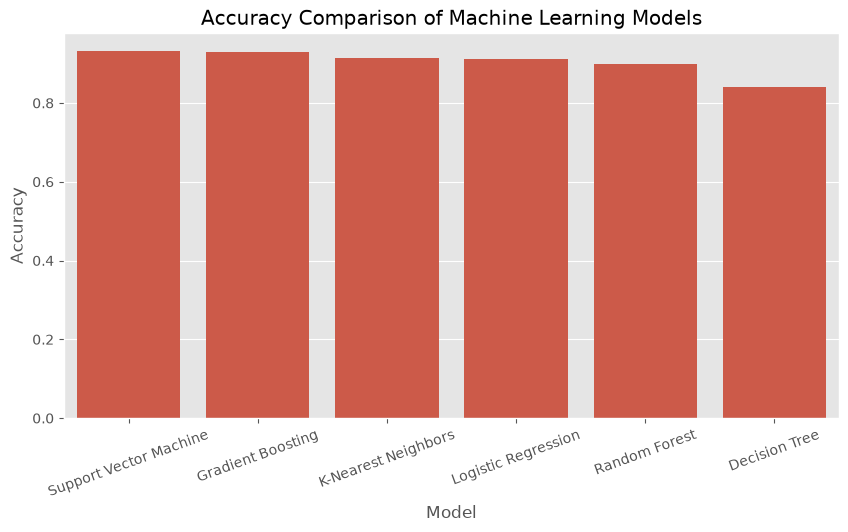

In [55]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.xticks(rotation=20)

plt.title("Accuracy Comparison of Machine Learning Models")

plt.show()

## 7.9 Model Evaluation Summary

### Summary

- Evaluated all trained machine learning models using the testing dataset.
- Calculated Accuracy, Precision, Recall, and F1-Score.
- Compared model performance using a summary table.
- Selected the best-performing model based on evaluation metrics.
- Generated a Classification Report.
- Visualized prediction performance using a Confusion Matrix.
- Compared model accuracies using a bar chart.

The best-performing model will be saved and deployed in the next phase.

# Part 8 - Model Saving

After identifying the best-performing machine learning model, the complete prediction pipeline is saved for future use. Saving the trained pipeline enables consistent preprocessing and prediction during deployment without retraining the model.

## 8.1 Import Required Library

The `joblib` library is used to serialize and save the trained machine learning pipeline.

In [57]:
# Import required library

import joblib

## 8.2 Save the Best Model Pipeline

The complete machine learning pipeline, including preprocessing and the trained classifier, is saved as a `.pkl` file.

In [58]:
# Save the best model pipeline

joblib.dump(best_model, "personality_classifier.pkl")

print("Model saved successfully.")

Model saved successfully.


## 8.3 Load the Saved Model

The saved model is loaded from disk to verify that it can be successfully restored.

In [59]:
# Load saved model

loaded_model = joblib.load("personality_classifier.pkl")

print("Model loaded successfully.")

Model loaded successfully.


## 8.4 Verify Loaded Model Type

The loaded object is inspected to confirm that the complete prediction pipeline has been restored successfully.

In [60]:
# Display model type

type(loaded_model)

sklearn.pipeline.Pipeline

## 8.5 Test the Loaded Model

The restored model is tested using a small sample from the testing dataset to ensure that predictions can be generated successfully.

In [61]:
# Generate predictions using loaded model

loaded_predictions = loaded_model.predict(X_test.head())

loaded_predictions

array(['Extrovert', 'Extrovert', 'Extrovert', 'Introvert', 'Introvert'],
      dtype=object)

## 8.6 Verify Prediction Consistency

The predictions generated by the loaded model are compared with those from the original trained model to ensure that both produce identical results.

In [62]:
# Compare predictions

original_predictions = best_model.predict(X_test.head())

comparison = original_predictions == loaded_predictions

print("Predictions Match :", comparison.all())

Predictions Match : True


## 8.7 Model Saving Summary

### Completed Tasks

- Imported the required serialization library.
- Saved the best-performing machine learning pipeline.
- Successfully loaded the saved model from disk.
- Verified the loaded model type.
- Generated predictions using the restored model.
- Confirmed that the loaded model produces the same predictions as the original trained model.

The saved model is now ready for deployment as a REST API in the next phase.